<a href="https://colab.research.google.com/github/eugeniodelrosalgp/metodos-numericos-1/blob/main/Metodo_de_biccecion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodo de biccecion

En este notebook estaremos programando **el metodo de biccecion** para la aproximacion de raices

Asi empezemos con la teoria.
este metodo usa fuertemente bel resultado del teorema intermedio que asegura que si $f(x)$ es una funcion continua denro del intervalo $[a,b]$ con $f(a), f(b)$ de signos opuestos
entonces existe $p$ en $(a,b)$ tal que $f(P)=0$

ahora ya que una funcion puede tener mas de una raiz en en un intervalo para la simplicidad de de este programa asumiermos que solo existe una raiz en el intervalo dado

por lo que tenemos que considerar algunas cosas antes de aplicar este metodo


<ol>
  <li>Considerar que l funcion en continua en $[a,b]$</li>
  <li>Verificar que $f(a)$ y $f(b)$ tienen signos opuestos es decir que $f(a) \times f(b)<0$</li>
</ol>
como se cumplen estas dos afirmaciones estonces el teorema del valor intermadio nos asegura la existencia de $p$ tal que $f(p)=0$

ya teniendo las condiciones necesarias veamos que es lo que onlleav este metodo

comenzemos, primero sea $a_1=a$ y $b_1=b$ y sea $p_1$ el punto medio de $[a,b]$ donde
$$
\begin{aligned}
p_1=a_1+\frac{b_1-a_1}{2}=\frac{a_1+b_1}{2}
\end{aligned}
$$

ahora
si $f(p_1)=0$ entonces hemos acabado ya que $p_1=p$
si $f(p_1)\neq0$ entonces existen dos casos
<ol>
  <li>si $f(p_1)$ y $f(a_1)$ tienen el mismo signo, entonces $a_2=p_1$ y $b_2=b_1$</li>
  <li>si $f(p_1)$ y $f(b_1)$ tienen el mismo signo, entonces $b_2=p_1$ y $a_2=a_1$</li>
</ol>
y se vuelve a repetir este algotitmo en el nuevo intervalo $[a_1,b_2]$ hasta que se encuantre una $p_i$ tal que satisfaga un error

el error se determina como
$$
\begin{aligned}
error=\rvert{a_1-b_1}\rvert
\end{aligned}
$$

## Ejemplo

En este caso queremos resolver la ecucion $f(x)=x^3+4x^2-10$ en el intervalo $[1,2]$ y que la raiz sea precisa por lo menos dentro de $10^{-4}$

como se menciono en la seccion de teoria empezemos con la condicion 1. veamos quye $f(x)$ es un polinomio por lo que esta es continua en el intervalo $[1,2]$,
ahora la condicion 2. veamos que $f(1)=-5$ y que $f(2)=14$
al comprobar estas dos condiciones el teorema del valor intermadio nos garantiza que existe una raiz en el intervalo$[a,b]$

ahora creemos un programa para calcular esta raiz para un error deseado o un numero de iteraciones indicado


In [1]:
#librerias importantes
import numpy as np
import matplotlib.pyplot as plt
#definimos la funcion f(x)
def f(x):
    return (x**3)+(4*x**2)-10.0
#intervalos
a=1
b=2
#guardamos los valores iniciales
a0=a
b0=b
#indica la tolerancia a la queremos que llege el error
tol=0.0001
#numero de iteraciones maxima si es que no llega a la toleracia adecuada
nmax=100
error=100
n=0

Text(0, 0.5, '$f(x)$')

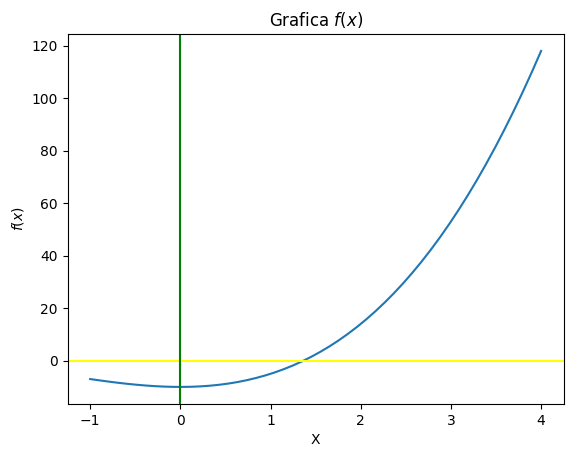

In [2]:
xx=np.linspace(a-2,b+2,50)
plt.plot(xx,f(xx))
plt.axhline(y=0,color="yellow")
plt.axvline(x=0,color="green")
plt.title("Grafica $f(x)$")
plt.xlabel("X")
plt.ylabel("$f(x)$")

In [3]:
# evaluo primer valor medio
p_i = a + (b - a)/2

#Evaluacion de la función en los puntos a, b y p_i
fa = f(a)
fb = f(b)
fp_i = f(p_i)
#tabla de valores
print("# iter\t\t a \t\t f(a) \t\t b \t\t f(b) \t\t m \t\t f(m) \t\t error")
print("{0} \t\t {1:6.4f} \t {2:6.4f} \t {3:6.4f} \t {4:6.4f} \t {5:6.4f} \t {6:6.4f} \t {7:6.4f}".format(n, a0, fa, b0, fb, p_i, fp_i, error ))

# ciclo iterativo
while error > tol and n < nmax:
    p_i = a + (b - a) / 2
    #checamos el signo de f(p_i) para ver que sub intervalo de la iteracion tomamos
    if np.sign(fa) == np.sign(fp_i):
        a = p_i
        fa = f(a)
    else:
        b = p_i
        fb = f(b)
    #calculamos el nuevo p_i para la siguiente iteracion
    p_i = a + (b - a)/2
    #evaluamos el nuevo p_i en f(x)
    fp_i = f(p_i)
    #calculamos el error de el nuevo intervalo para luego checar si satisface la condicion inicial
    error = abs(b - a)
    n += 1
    #imprimimos los valores calculados de dicha funcion
    print("{0} \t\t {1:6.6f} \t {2:6.6f} \t {3:6.6f} \t {4:6.6f} \t {5:6.6f} \t {6:6.6f} \t {7:6.6f}".format(n, a, fa, b, fb, p_i, fp_i, error ))

print("La raíz de la función dada en el intervalo [{0:6.4f},{1:6.4f}] es {2:6.7f}".format(a0,b0,p_i))

# iter		 a 		 f(a) 		 b 		 f(b) 		 m 		 f(m) 		 error
0 		 1.0000 	 -5.0000 	 2.0000 	 14.0000 	 1.5000 	 2.3750 	 100.0000
1 		 1.000000 	 -5.000000 	 1.500000 	 2.375000 	 1.250000 	 -1.796875 	 0.500000
2 		 1.250000 	 -1.796875 	 1.500000 	 2.375000 	 1.375000 	 0.162109 	 0.250000
3 		 1.250000 	 -1.796875 	 1.375000 	 0.162109 	 1.312500 	 -0.848389 	 0.125000
4 		 1.312500 	 -0.848389 	 1.375000 	 0.162109 	 1.343750 	 -0.350983 	 0.062500
5 		 1.343750 	 -0.350983 	 1.375000 	 0.162109 	 1.359375 	 -0.096409 	 0.031250
6 		 1.359375 	 -0.096409 	 1.375000 	 0.162109 	 1.367188 	 0.032356 	 0.015625
7 		 1.359375 	 -0.096409 	 1.367188 	 0.032356 	 1.363281 	 -0.032150 	 0.007812
8 		 1.363281 	 -0.032150 	 1.367188 	 0.032356 	 1.365234 	 0.000072 	 0.003906
9 		 1.363281 	 -0.032150 	 1.365234 	 0.000072 	 1.364258 	 -0.016047 	 0.001953
10 		 1.364258 	 -0.016047 	 1.365234 	 0.000072 	 1.364746 	 -0.007989 	 0.000977
11 		 1.364746 	 -0.007989 	 1.365234 	 0.000072 	 1.36499